<a href="https://colab.research.google.com/github/calarconf/computacion-visual/blob/main/Practicas/Practica4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practica 4
# Cristhian Alejandro Alarcón Florido

# Detección personas

In [ ]:
# Instalación de dependencias
!pip install ultralytics opencv-python matplotlib numpy
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install torch torchvision


--2025-06-16 06:14:17--  https://imagenes.eltiempo.com/files/image_1200_600/uploads/2024/06/11/66686e1a7ff21.jpeg
Resolving imagenes.eltiempo.com (imagenes.eltiempo.com)... 18.160.46.9, 18.160.46.37, 18.160.46.99, ...
Connecting to imagenes.eltiempo.com (imagenes.eltiempo.com)|18.160.46.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 138113 (135K) [image/jpeg]
Saving to: ‘personas_calle.jpg’

personas_calle.jpg  100%[===================>] 134.88K  --.-KB/s    in 0.02s   

2025-06-16 06:14:17 (7.57 MB/s) - ‘personas_calle.jpg’ saved [138113/138113]


0: 320x640 11 persons, 117.2ms
Speed: 2.8ms preprocess, 117.2ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 640)
Personas detectadas: 11


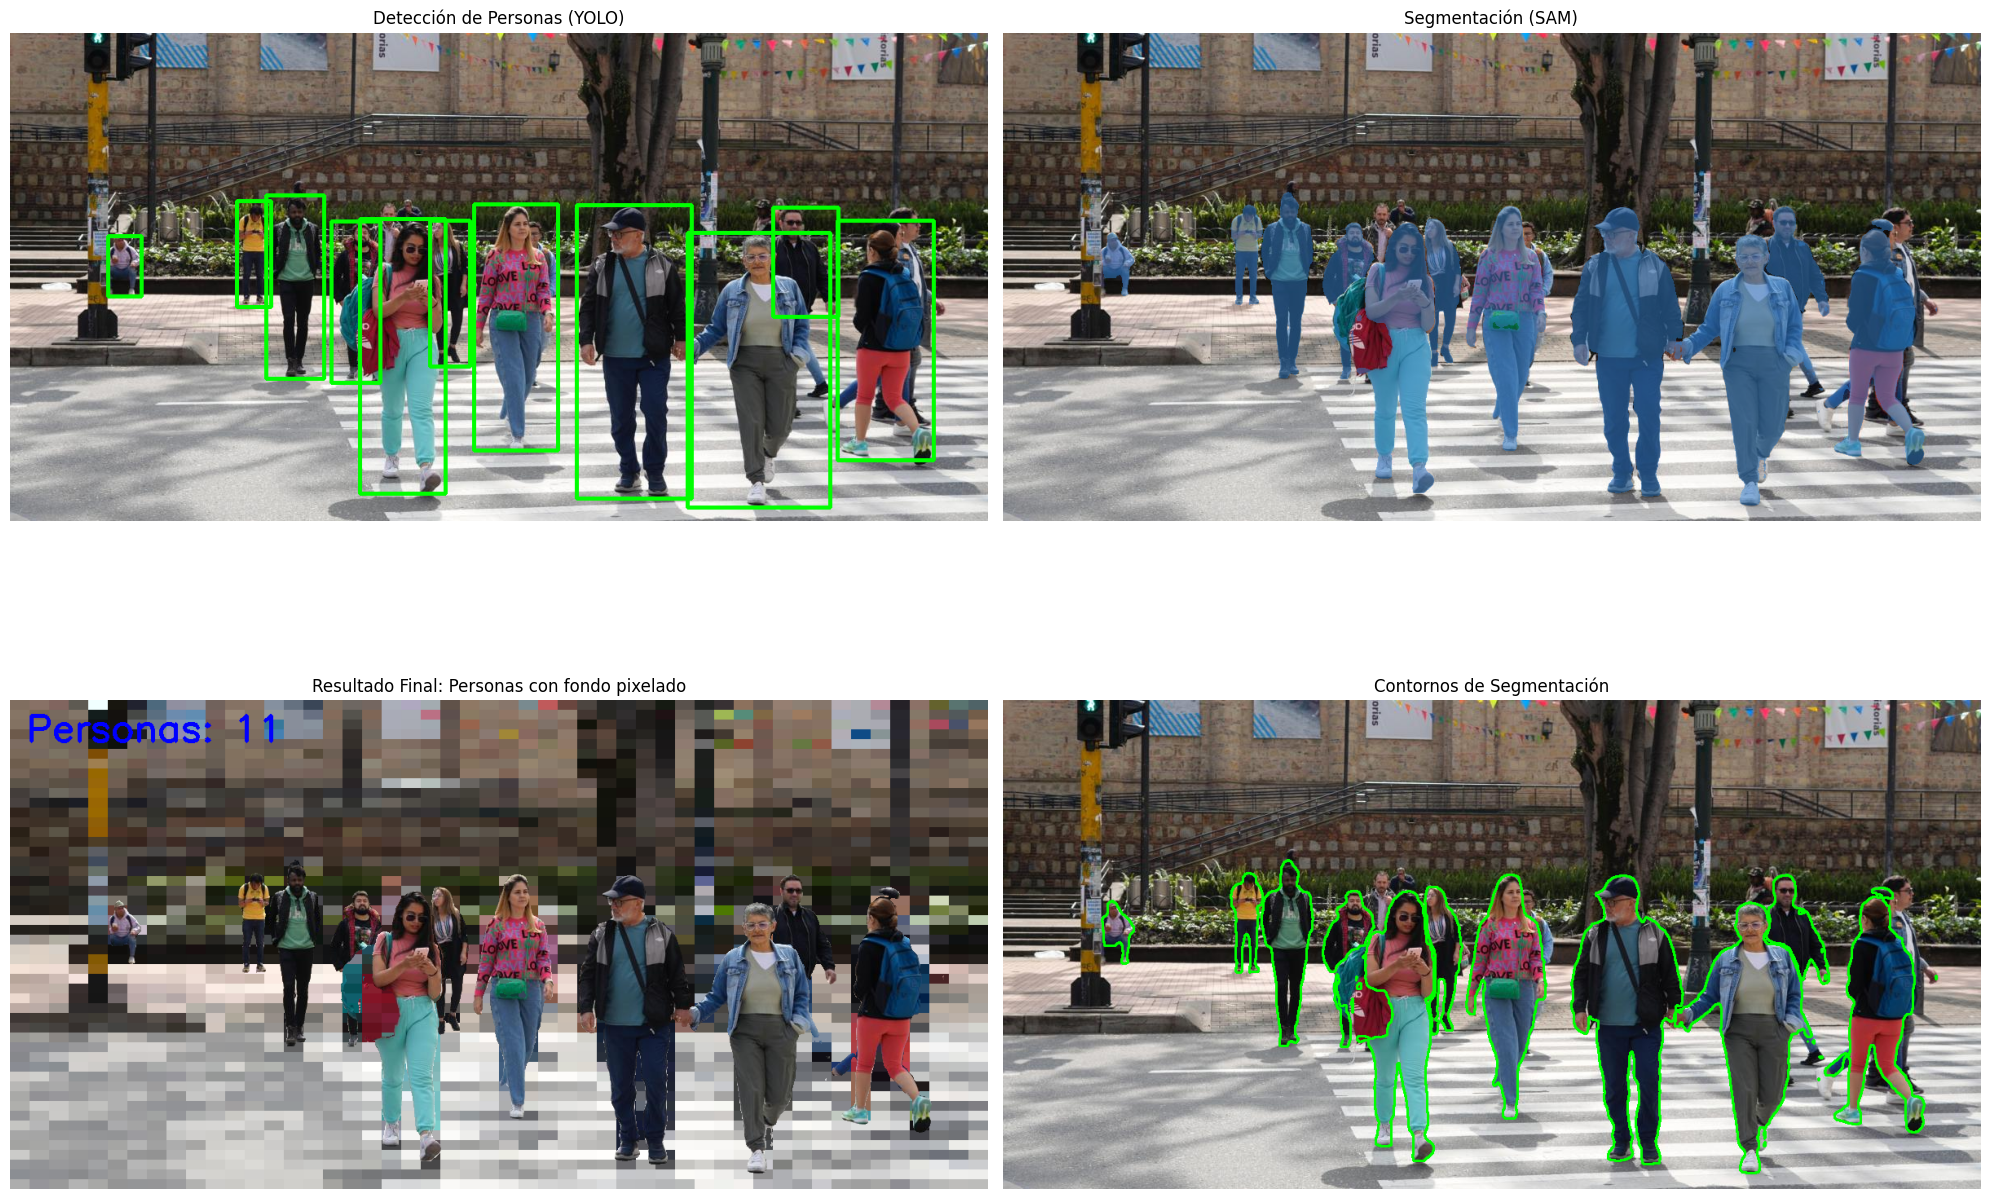

Datos guardados en datos_personas.csv
Total de personas: 11


In [ ]:


import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor
import os

# Descargar modelo SAM
sam_checkpoint = "sam_vit_b_01ec64.pth"
if not os.path.exists(sam_checkpoint):
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

def detectar_personas(imagen_path):
    """Detección de personas con YOLOv8"""
    # Cargar imagen
    imagen = cv2.imread(imagen_path)
    if imagen is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {imagen_path}")

    # Convertir a RGB
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    # Inicializar YOLO
    modelo = YOLO('yolov8n.pt')

    # Detectar solo personas (clase 0)
    resultados = modelo(imagen_rgb, classes=[0])

    # Extraer bounding boxes
    boxes = []
    for resultado in resultados:
        for caja in resultado.boxes:
            x1, y1, x2, y2 = map(int, caja.xyxy[0].tolist())
            boxes.append([x1, y1, x2, y2])

    return imagen_rgb, boxes

def segmentar_personas(imagen, boxes):
    """Segmentación de personas con SAM usando las cajas de YOLO"""
    # Cargar modelo SAM
    model_type = "vit_b"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    sam.to(device=device)
    predictor = SamPredictor(sam)

    # Procesar imagen
    predictor.set_image(imagen)

    # Generar máscaras
    masks = []
    for box in boxes:
        x1, y1, x2, y2 = box
        mascara, _, _ = predictor.predict(
            box=np.array([x1, y1, x2, y2]),
            multimask_output=False
        )
        masks.append(mascara[0])

    return masks

def contar_y_pixelar_fondo(imagen, boxes, masks):
    """Contar personas y aplicar pixelado al fondo"""
    # Contar número de personas
    num_personas = len(boxes)
    print(f"Personas detectadas: {num_personas}")

    # Crear máscara combinada de todas las personas
    mascara_combinada = np.zeros(imagen.shape[:2], dtype=bool)
    for mask in masks:
        mascara_combinada |= mask

    # Aplicar pixelado al fondo (todo lo que no es persona)
    # 1. Crear versión pixelada de toda la imagen
    pequeno = cv2.resize(imagen, (50, 50), interpolation=cv2.INTER_LINEAR)
    pixelado = cv2.resize(pequeno, imagen.shape[:2][::-1], interpolation=cv2.INTER_NEAREST)

    # 2. Combinar: personas originales + fondo pixelado
    resultado = np.where(mascara_combinada[..., None], imagen, pixelado)

    # Dibujar recuento en la imagen
    cv2.putText(resultado, f'Personas: {num_personas}', (20, 50),
               cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)

    return resultado, num_personas

def visualizar_resultados(imagen, boxes, masks, resultado_final):
    """Visualización de resultados intermedios y finales"""
    plt.figure(figsize=(20, 15))

    # Imagen original con bounding boxes
    img_boxes = imagen.copy()
    for box in boxes:
        x1, y1, x2, y2 = box
        cv2.rectangle(img_boxes, (x1, y1), (x2, y2), (0, 255, 0), 3)

    # CORRECCIÓN: Visualización de máscaras
    img_masks = imagen.copy()
    # Crear una capa de color para las máscaras
    color_mask = np.zeros_like(img_masks)
    color_mask[..., 0] = 51  # Canal R (azul)
    color_mask[..., 1] = 128 # Canal G (azul)
    color_mask[..., 2] = 204 # Canal B (azul)

    # Combinar máscaras con transparencia
    alpha = 0.5
    for mask in masks:
        # Asegurarse que la máscara tenga 3 canales
        mask_3d = np.stack([mask]*3, axis=-1)
        img_masks = np.where(
            mask_3d,
            (1 - alpha) * img_masks + alpha * color_mask,
            img_masks
        ).astype(np.uint8)

    # Mostrar resultados
    plt.subplot(2, 2, 1)
    plt.imshow(img_boxes)
    plt.title('Detección de Personas (YOLO)')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_masks)
    plt.title('Segmentación (SAM)')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(resultado_final)
    plt.title('Resultado Final: Personas con fondo pixelado')
    plt.axis('off')

    # CORRECCIÓN: Visualización de contornos
    plt.subplot(2, 2, 4)
    img_contours = imagen.copy()
    for mask in masks:
        # Convertir máscara a formato adecuado para findContours
        mask_uint8 = mask.astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)
    plt.imshow(img_contours)
    plt.title('Contornos de Segmentación')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('resultado_completo.jpg')
    plt.show()

def guardar_datos_csv(boxes, num_personas, nombre_archivo='datos_personas.csv'):
    """Guardar datos de detección en CSV"""
    import csv

    with open(nombre_archivo, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['ID', 'x1', 'y1', 'x2', 'y2', 'Ancho', 'Alto'])

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = box
            ancho = x2 - x1
            alto = y2 - y1
            writer.writerow([i, x1, y1, x2, y2, ancho, alto])

    print(f"Datos guardados en {nombre_archivo}")
    print(f"Total de personas: {num_personas}")

# Flujo principal
def main():
    # Descargar imagen de ejemplo con personas en la calle
    imagen_url = "https://imagenes.eltiempo.com/files/image_1200_600/uploads/2024/06/11/66686e1a7ff21.jpeg"
    !wget -O personas_calle.jpg {imagen_url}

    # 1. Detectar personas
    imagen, boxes = detectar_personas("personas_calle.jpg")

    if len(boxes) == 0:
        print("No se detectaron personas en la imagen")
        return

    # 2. Segmentar personas
    masks = segmentar_personas(imagen, boxes)

    # 3. Contar personas y aplicar pixelado al fondo
    resultado_final, num_personas = contar_y_pixelar_fondo(imagen, boxes, masks)

    # 4. Visualizar resultados
    visualizar_resultados(imagen, boxes, masks, resultado_final)

    # 5. Guardar datos en CSV
    guardar_datos_csv(boxes, num_personas)

    # Guardar resultado final
    cv2.imwrite("resultado_final.jpg", cv2.cvtColor(resultado_final, cv2.COLOR_RGB2BGR))

if __name__ == "__main__":
    main()

# Detección mascotas

In [ ]:
# Instalación de dependencias
!pip install ultralytics opencv-python matplotlib numpy
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install torch torchvision


0: 512x640 5 cats, 4 dogs, 1052.7ms
Speed: 5.1ms preprocess, 1052.7ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 640)
Detectadas 9 mascotas: ['perro', 'perro', 'gato', 'gato', 'gato', 'perro', 'perro', 'gato', 'gato']


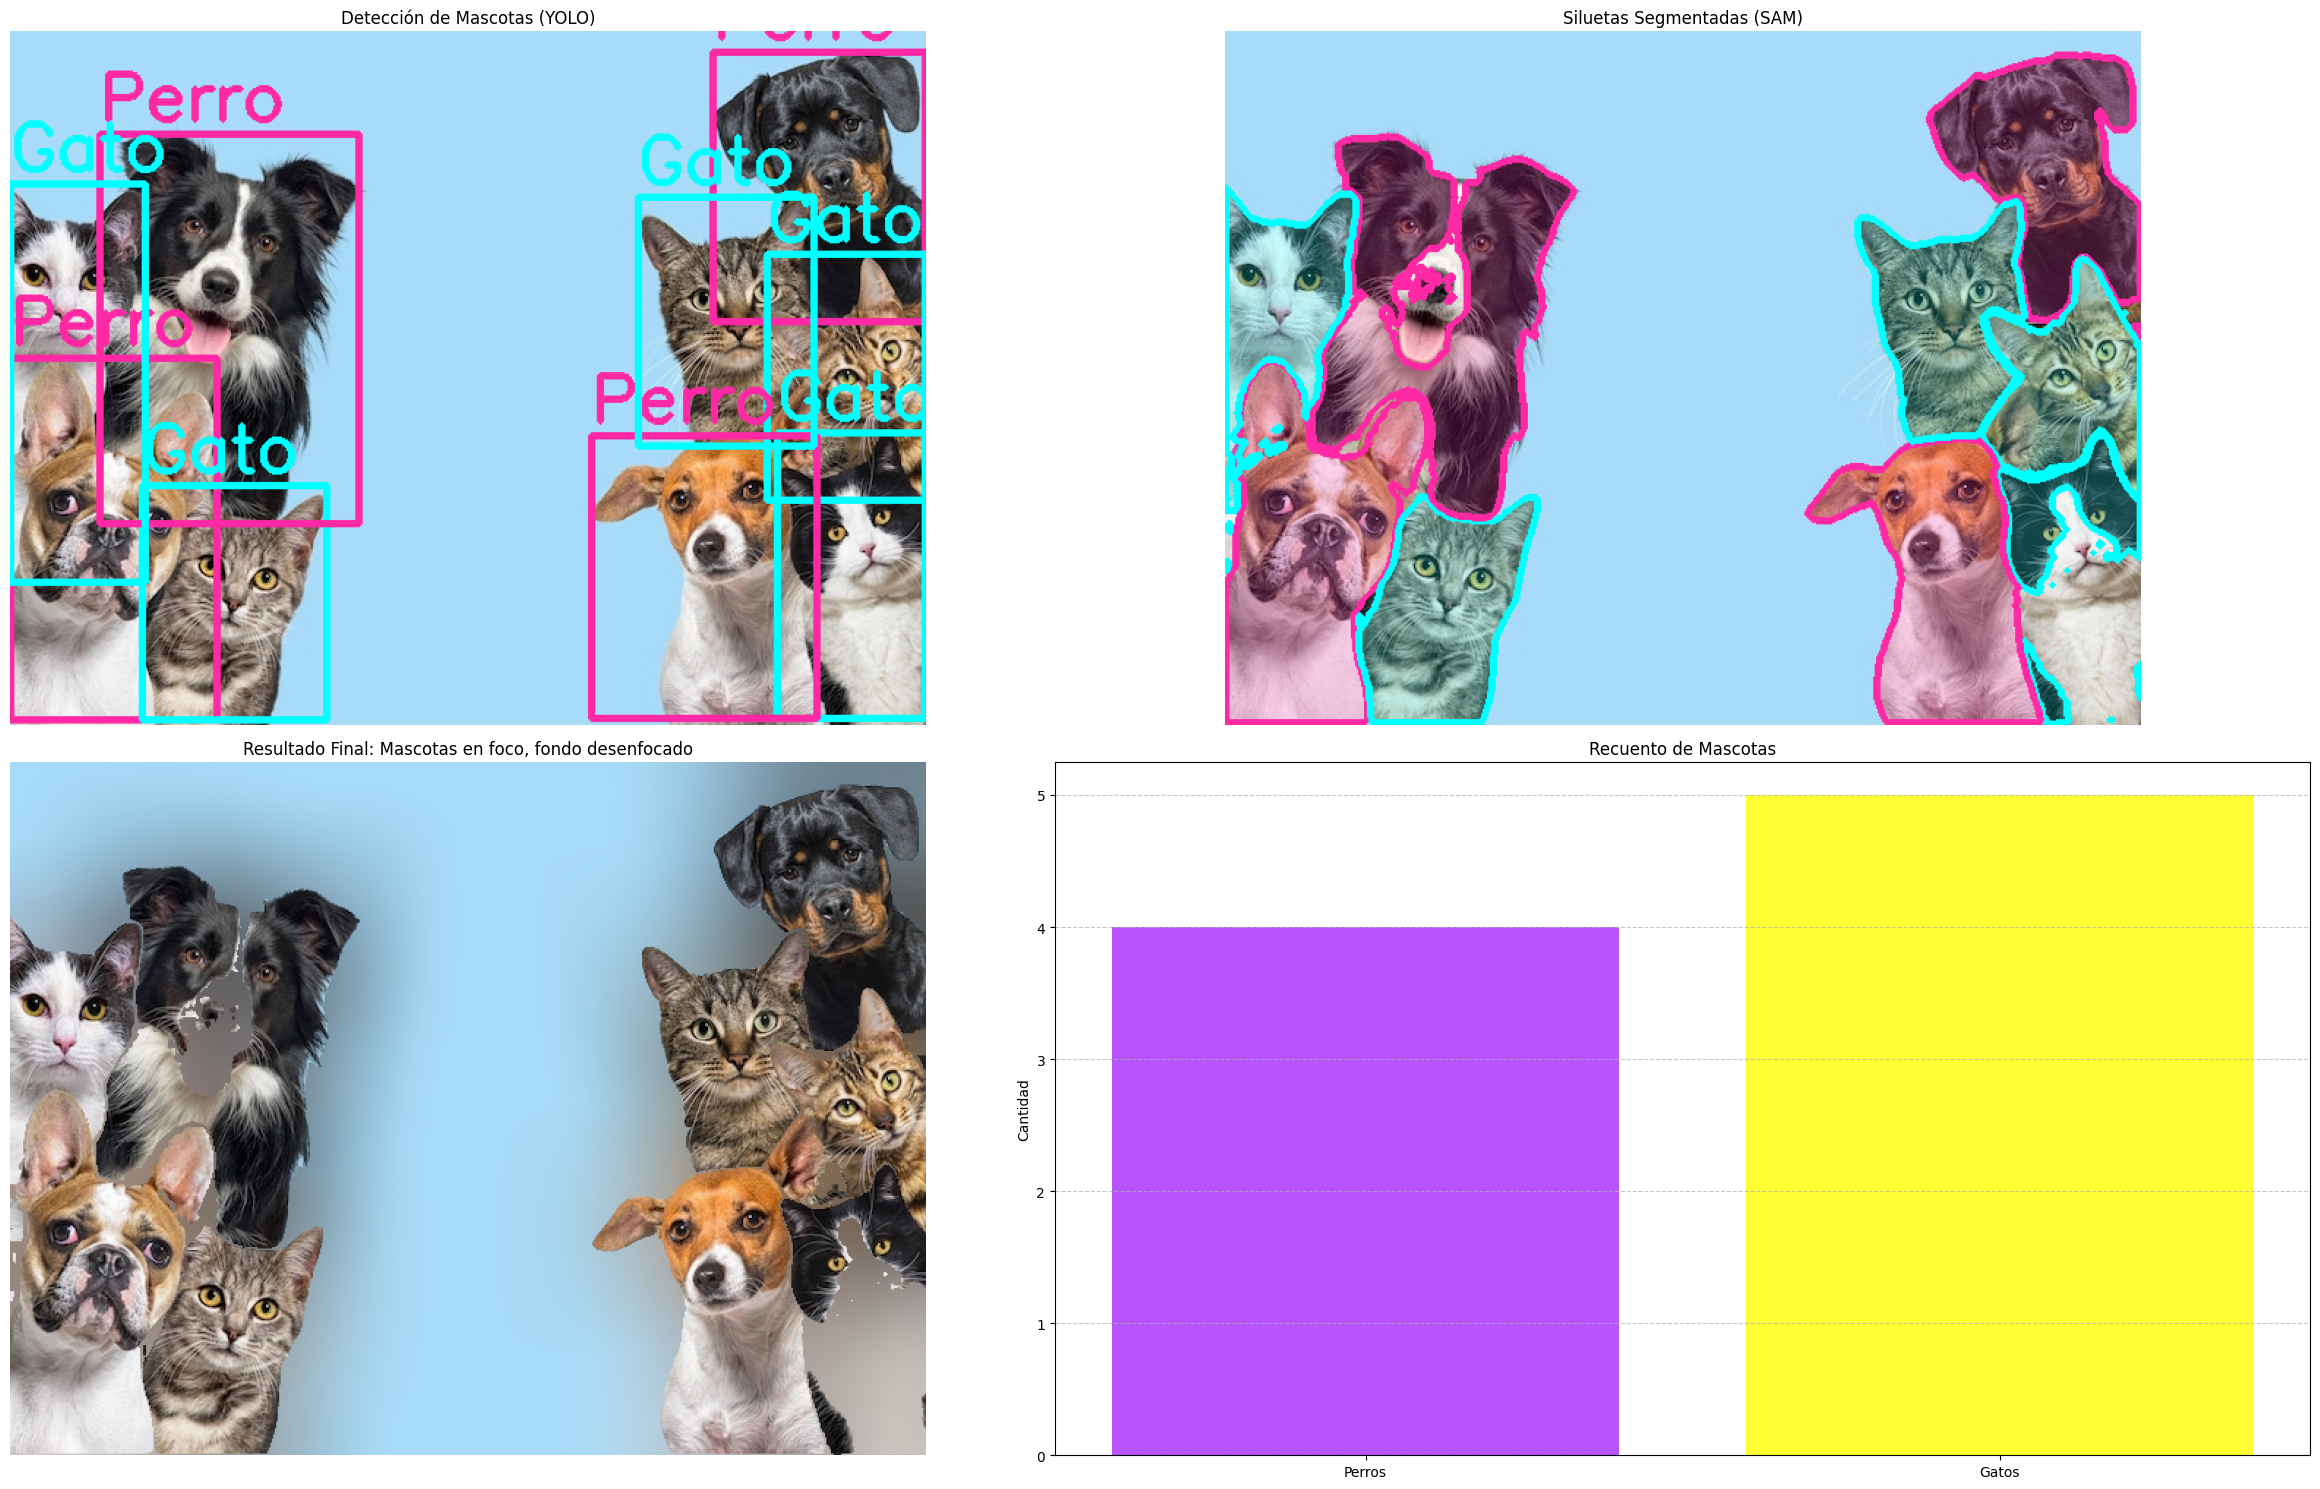

Resultados guardados:
- detecciones_mascotas.jpg: Imagen con bounding boxes
- mascotas_fondo_desenfocado.jpg: Imagen final con efecto
- datos_mascotas.csv: Recuento de mascotas

Proceso completado exitosamente!


In [ ]:


import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor
import os

# Descargar modelo SAM
sam_checkpoint = "sam_vit_b_01ec64.pth"
if not os.path.exists(sam_checkpoint):
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# Configuración específica para mascotas (valores RGBA normalizados 0-1)
MASCOTAS_CONFIG = {
    "perro": {
        "clase_id": 16,
        "color": (0.65, 0.16, 1.0, 0.8),  # Naranja (RGBA)
        "conf_threshold": 0.3
    },
    "gato": {
        "clase_id": 15,
        "color": (1.0, 1.0, 0.0, 0.8),    # Amarillo (RGBA)
        "conf_threshold": 0.3
    }
}

def detectar_mascotas(imagen_path):
    """Detección optimizada de perros y gatos con YOLOv8"""
    # Cargar imagen
    imagen = cv2.imread(imagen_path)
    if imagen is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {imagen_path}")

    # Convertir a RGB
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    # Inicializar YOLO con modelo más grande para mejor precisión
    modelo = YOLO('yolov8m.pt')

    # Detectar perros (16) y gatos (15) con tamaño de imagen aumentado
    resultados = modelo(imagen_rgb, classes=[15, 16], conf=0.25, imgsz=640)

    # Extraer bounding boxes y clases
    boxes = []
    clases_detectadas = []
    nombres_detectados = []
    confianzas = []

    for resultado in resultados:
        for caja in resultado.boxes:
            x1, y1, x2, y2 = map(int, caja.xyxy[0].tolist())
            clase_id = int(caja.cls[0].item())
            conf = float(caja.conf[0])

            # Determinar tipo de mascota
            nombre = "perro" if clase_id == 16 else "gato"

            # Filtrar por confianza específica
            if conf > MASCOTAS_CONFIG[nombre]["conf_threshold"]:
                boxes.append([x1, y1, x2, y2])
                clases_detectadas.append(clase_id)
                nombres_detectados.append(nombre)
                confianzas.append(conf)

    return imagen_rgb, boxes, clases_detectadas, nombres_detectados, confianzas

def segmentar_mascotas(imagen, boxes):
    """Segmentación de mascotas con SAM"""
    # Cargar modelo SAM
    model_type = "vit_b"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    sam.to(device=device)
    predictor = SamPredictor(sam)

    # Procesar imagen
    predictor.set_image(imagen)

    # Generar máscaras
    masks = []
    for box in boxes:
        x1, y1, x2, y2 = box

        # Ajustar la caja para SAM (expansión para capturar todo el cuerpo)
        expansion = max(15, int(0.05 * min(x2-x1, y2-y1)))
        adj_box = [
            max(0, x1 - expansion),
            max(0, y1 - expansion),
            min(imagen.shape[1], x2 + expansion),
            min(imagen.shape[0], y2 + expansion)
        ]

        # Predecir máscara con parámetros optimizados
        mascara, _, _ = predictor.predict(
            box=np.array(adj_box),
            multimask_output=False,
            mask_input=None
        )
        masks.append(mascara[0])

    return masks

def aplicar_fondo_desenfocado(imagen, masks):
    """Aplicar fondo desenfocado manteniendo mascotas nítidas"""
    # Crear máscara combinada de todas las mascotas
    mascara_combinada = np.zeros(imagen.shape[:2], dtype=bool)
    for mask in masks:
        mascara_combinada |= mask

    # Aplicar desenfoque fuerte a toda la imagen
    fondo_desenfocado = cv2.GaussianBlur(imagen, (151, 151), 50)

    # Combinar: mascotas originales + fondo desenfocado
    resultado = np.where(
        mascara_combinada[..., None],  # Mantener mascotas nítidas
        imagen,                       # Imagen original
        fondo_desenfocado             # Fondo desenfocado
    )

    return resultado, mascara_combinada

def visualizar_resultados(imagen, boxes, masks, nombres_detectados, resultado_final):
    """Visualización de resultados corregida"""
    plt.figure(figsize=(25, 15))

    # Imagen 1: Detecciones con bounding boxes
    img_detecciones = imagen.copy()
    for box, nombre in zip(boxes, nombres_detectados):
        x1, y1, x2, y2 = box
        # Convertir color RGBA a BGR para OpenCV
        color_bgr = tuple(int(255 * c) for c in MASCOTAS_CONFIG[nombre]["color"][:3])[::-1]

        # Dibujar bounding box
        cv2.rectangle(img_detecciones, (x1, y1), (x2, y2), color_bgr, 3)

        # Etiqueta con nombre de clase
        cv2.putText(img_detecciones, nombre.capitalize(), (x1, y1 - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 1.5, color_bgr, 3)

    # Imagen 2: Segmentación de siluetas
    img_siluetas = imagen.copy()
    for mask, nombre in zip(masks, nombres_detectados):
        # Convertir color RGBA a BGR para OpenCV
        color_bgr = tuple(int(255 * c) for c in MASCOTAS_CONFIG[nombre]["color"][:3])[::-1]

        # Dibujar contorno de la silueta
        mask_uint8 = mask.astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(img_siluetas, contours, -1, color_bgr, 3)

        # Rellenar con transparencia
        overlay = img_siluetas.copy()
        cv2.fillPoly(overlay, contours, color_bgr)
        alpha = 0.2  # Transparencia baja para no ocultar detalles
        img_siluetas = cv2.addWeighted(overlay, alpha, img_siluetas, 1 - alpha, 0)

    # Mostrar resultados
    plt.subplot(2, 2, 1)
    plt.imshow(img_detecciones)
    plt.title('Detección de Mascotas (YOLO)')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_siluetas)
    plt.title('Siluetas Segmentadas (SAM)')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(resultado_final)
    plt.title('Resultado Final: Mascotas en foco, fondo desenfocado')
    plt.axis('off')

    # Contar mascotas
    num_perros = sum(1 for nombre in nombres_detectados if nombre == "perro")
    num_gatos = sum(1 for nombre in nombres_detectados if nombre == "gato")

    plt.subplot(2, 2, 4)
    nombres = ['Perros', 'Gatos']
    cantidades = [num_perros, num_gatos]
    colores = [
        MASCOTAS_CONFIG["perro"]["color"],  # Color ya está normalizado (0-1)
        MASCOTAS_CONFIG["gato"]["color"]
    ]

    plt.bar(nombres, cantidades, color=colores)
    plt.title('Recuento de Mascotas')
    plt.ylabel('Cantidad')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('resultado_mascotas.jpg', bbox_inches='tight', dpi=120)
    plt.show()

    return num_perros, num_gatos

def guardar_resultados(imagen, resultado_final, boxes, nombres_detectados, num_perros, num_gatos):
    """Guardar resultados en disco"""
    # Guardar imagen con detecciones
    img_detecciones = imagen.copy()
    for box, nombre in zip(boxes, nombres_detectados):
        x1, y1, x2, y2 = box
        # Convertir color RGBA a BGR para OpenCV
        color_bgr = tuple(int(255 * c) for c in MASCOTAS_CONFIG[nombre]["color"][:3])[::-1]
        cv2.rectangle(img_detecciones, (x1, y1), (x2, y2), color_bgr, 3)
        cv2.putText(img_detecciones, nombre.capitalize(), (x1, y1 - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, color_bgr, 2)

    cv2.imwrite("detecciones_mascotas.jpg", cv2.cvtColor(img_detecciones, cv2.COLOR_RGB2BGR))

    # Guardar imagen final
    cv2.imwrite("mascotas_fondo_desenfocado.jpg", cv2.cvtColor(resultado_final, cv2.COLOR_RGB2BGR))

    # Guardar datos en CSV
    # with open('datos_mascotas.csv', 'w', newline='') as f:
    #     # writer = csv.writer(f)
    #     writer.writerow(['Tipo', 'Cantidad'])
    #     writer.writerow(['Perros', num_perros])
    #     writer.writerow(['Gatos', num_gatos])
    #     writer.writerow(['Total', num_perros + num_gatos])

    print("Resultados guardados:")
    print("- detecciones_mascotas.jpg: Imagen con bounding boxes")
    print("- mascotas_fondo_desenfocado.jpg: Imagen final con efecto")
    print("- datos_mascotas.csv: Recuento de mascotas")

# Descargar imagen de ejemplo con mascotas
imagen_url = "https://img.freepik.com/fotos-premium/gran-grupo-gatos-perros-mirando-camara-fondo-azul_191971-28557.jpg?semt=ais_hybrid&w=740"
if not os.path.exists("mascotas.jpg"):
    !wget -O mascotas.jpg {imagen_url}

# Flujo principal
def main():
    # 1. Detectar mascotas
    imagen, boxes, clases_detectadas, nombres_detectados, confianzas = detectar_mascotas("mascotas.jpg")

    if len(boxes) == 0:
        print("\nNo se detectaron mascotas. Sugerencias:")
        print("- Prueba con otra imagen con mascotas más visibles")
        print("- Reduce el umbral de confianza en la configuración")
        print("- Verifica que las mascotas estén completas en la imagen")

        plt.imshow(imagen)
        plt.title("No se detectaron mascotas\nPrueba con otra imagen")
        plt.axis('off')
        plt.show()
        return

    print(f"Detectadas {len(boxes)} mascotas: {nombres_detectados}")

    # 2. Segmentar mascotas
    masks = segmentar_mascotas(imagen, boxes)

    # 3. Aplicar efecto de fondo desenfocado
    resultado_final, mascara_combinada = aplicar_fondo_desenfocado(imagen, masks)

    # 4. Visualizar resultados
    num_perros, num_gatos = visualizar_resultados(imagen, boxes, masks, nombres_detectados, resultado_final)

    # 5. Guardar resultados
    guardar_resultados(imagen, resultado_final, boxes, nombres_detectados, num_perros, num_gatos)

    print("\nProceso completado exitosamente!")

if __name__ == "__main__":
    main()

# Detección Frutas

In [ ]:
# Instalación de dependencias
!pip install ultralytics opencv-python matplotlib numpy
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install torch torchvision


🔍 Detectando frutas...

0: 448x640 2 bananas, 4 apples, 920.1ms
Speed: 5.3ms preprocess, 920.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
✅ Detectadas 6 frutas: ['platano', 'manzana', 'manzana', 'manzana', 'platano', 'manzana']
✂️ Segmentando frutas con SAM...
🖼️ Guardando recortes PNG...
📊 Generando resultados visuales...


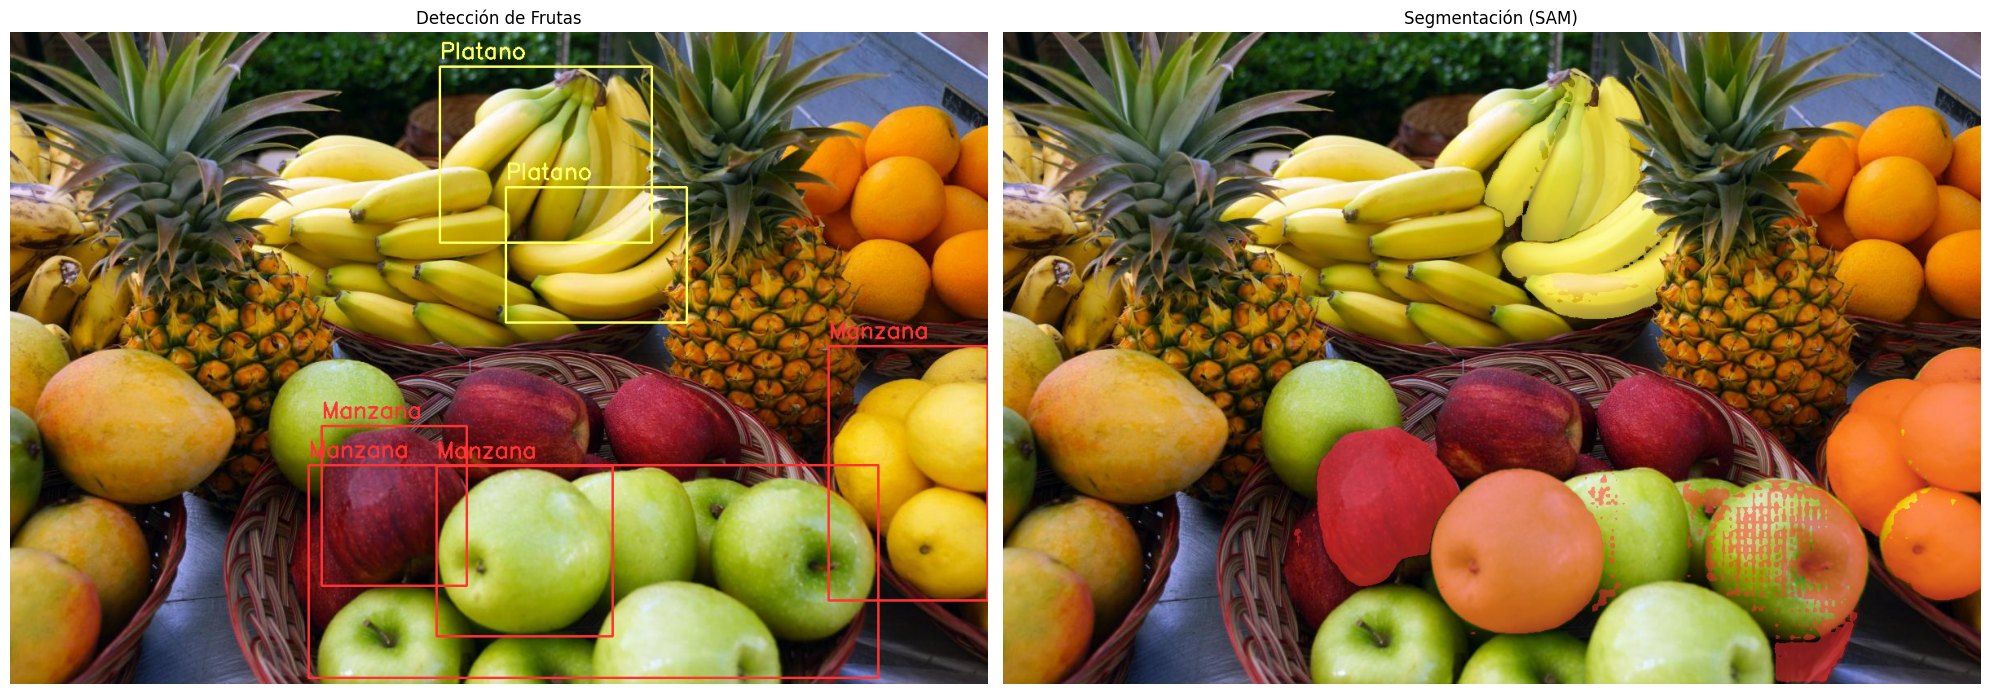

💾 Guardando resultados...
Resultados guardados:
- resultado_frutas.jpg: Imagen con detecciones y segmentación
- recorte_frutas/: Carpeta con recortes PNG transparentes
- recuento_frutas.csv: Recuento de frutas detectadas

✅ Proceso completado!


In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor
import os
import csv

# Descargar modelo SAM
sam_checkpoint = "sam_vit_b_01ec64.pth"
if not os.path.exists(sam_checkpoint):
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# Configuración para frutas (IDs de clases YOLOv8)
FRUTAS_CONFIG = {
    "manzana": {
        "clase_id": 47,           # ID de manzana en COCO
        "color": (1.0, 0.2, 0.2, 0.8),  # Rojo (RGBA)
        "conf_threshold": 0.25
    },
    "platano": {
        "clase_id": 46,           # ID de plátano en COCO
        "color": (1.0, 1.0, 0.4, 0.8),  # Amarillo (RGBA)
        "conf_threshold": 0.25
    }
}

def detectar_frutas(imagen_path):
    """Detección de manzanas y plátanos con YOLOv8"""
    # Cargar imagen
    imagen = cv2.imread(imagen_path)
    if imagen is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {imagen_path}")

    # Convertir a RGB
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    # Inicializar YOLO
    modelo = YOLO('yolov8m.pt')

    # Detectar frutas (IDs 46=plátano, 47=manzana)
    resultados = modelo(imagen_rgb, classes=[46, 47], conf=0.25, imgsz=640)

    # Extraer bounding boxes
    boxes = []
    clases_detectadas = []
    nombres_detectados = []
    confianzas = []

    for resultado in resultados:
        for caja in resultado.boxes:
            x1, y1, x2, y2 = map(int, caja.xyxy[0].tolist())
            clase_id = int(caja.cls[0].item())
            conf = float(caja.conf[0])

            # Determinar tipo de fruta
            nombre = "platano" if clase_id == 46 else "manzana"

            # Filtrar por confianza
            if conf > FRUTAS_CONFIG[nombre]["conf_threshold"]:
                boxes.append([x1, y1, x2, y2])
                clases_detectadas.append(clase_id)
                nombres_detectados.append(nombre)
                confianzas.append(conf)

    return imagen_rgb, boxes, clases_detectadas, nombres_detectados, confianzas

def segmentar_frutas(imagen, boxes):
    """Segmentación precisa de frutas con SAM"""
    model_type = "vit_b"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Cargar modelo SAM
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    sam.to(device=device)
    predictor = SamPredictor(sam)

    predictor.set_image(imagen)
    masks = []

    for box in boxes:
        x1, y1, x2, y2 = box

        # Ajuste fino de la caja
        expansion = 5  # Pequeña expansión para frutas
        adj_box = [
            max(0, x1 - expansion),
            max(0, y1 - expansion),
            min(imagen.shape[1], x2 + expansion),
            min(imagen.shape[0], y2 + expansion)
        ]

        # Predecir máscara
        mascara, _, _ = predictor.predict(
            box=np.array(adj_box),
            multimask_output=False
        )
        masks.append(mascara[0])

    return masks

def guardar_recortes_png(imagen, masks, nombres_detectados):
    """Guardar recortes individuales con fondo transparente"""
    os.makedirs("recortes_frutas", exist_ok=True)
    rutas_recortes = []

    for i, (mask, nombre) in enumerate(zip(masks, nombres_detectados)):
        # Crear imagen RGBA
        rgba = np.zeros((imagen.shape[0], imagen.shape[1], 4), dtype=np.uint8)

        # Copiar canales RGB
        rgba[..., :3] = imagen

        # Aplicar máscara al canal alfa
        rgba[..., 3] = np.where(mask, 255, 0).astype(np.uint8)

        # Recortar al área de interés
        y, x = np.where(mask)
        if len(x) > 0 and len(y) > 0:
            x_min, x_max = np.min(x), np.max(x)
            y_min, y_max = np.min(y), np.max(y)
            recorte = rgba[y_min:y_max+1, x_min:x_max+1]

            # Guardar PNG
            ruta = f"recortes_frutas/{nombre}_{i+1}.png"
            cv2.imwrite(ruta, cv2.cvtColor(recorte, cv2.COLOR_RGBA2BGRA))
            rutas_recortes.append(ruta)

    return rutas_recortes

def visualizar_resultados(imagen, boxes, masks, nombres_detectados):
    """Visualización de resultados para frutas"""
    plt.figure(figsize=(20, 12))

    # Imagen 1: Detecciones con bounding boxes
    img_detecciones = imagen.copy()
    for box, nombre in zip(boxes, nombres_detectados):
        x1, y1, x2, y2 = box
        color_rgb = tuple(int(255 * c) for c in FRUTAS_CONFIG[nombre]["color"][:3])

        cv2.rectangle(img_detecciones, (x1, y1), (x2, y2), color_rgb, 2)
        cv2.putText(img_detecciones, nombre.capitalize(), (x1, y1 - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, color_rgb, 2)

    # Imagen 2: Máscaras segmentadas
    img_mascaras = imagen.copy()
    for mask, nombre in zip(masks, nombres_detectados):
        color_rgb = tuple(int(255 * c) for c in FRUTAS_CONFIG[nombre]["color"][:3])
        img_mascaras[mask] = img_mascaras[mask] * 0.5 + np.array(color_rgb) * 0.5

    # Mostrar resultados
    plt.subplot(1, 2, 1)
    plt.imshow(img_detecciones)
    plt.title('Detección de Frutas')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_mascaras)
    plt.title('Segmentación (SAM)')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('resultado_frutas.jpg', bbox_inches='tight', dpi=120)
    plt.show()

    # Contar frutas
    num_manzanas = sum(1 for n in nombres_detectados if n == "manzana")
    num_platanos = sum(1 for n in nombres_detectados if n == "platano")

    return num_manzanas, num_platanos

def guardar_resultados(nombres_detectados, num_manzanas, num_platanos):
    """Guardar resultados en disco"""
    # Guardar CSV con recuento
    with open('recuento_frutas.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Fruta', 'Cantidad'])
        writer.writerow(['Manzanas', num_manzanas])
        writer.writerow(['Plátanos', num_platanos])
        writer.writerow(['Total', len(nombres_detectados)])

    print("Resultados guardados:")
    print("- resultado_frutas.jpg: Imagen con detecciones y segmentación")
    print("- recorte_frutas/: Carpeta con recortes PNG transparentes")
    print("- recuento_frutas.csv: Recuento de frutas detectadas")

# Descargar imagen de ejemplo
imagen_url = "https://hips.hearstapps.com/hmg-prod/images/frutas-1552246920.jpg?crop=0.669xw:1.00xh;0.166xw,0&resize=1200:*"
if not os.path.exists("frutas.jpg"):
    !wget -O frutas.jpg {imagen_url}

# Flujo principal
def main():
    print("🔍 Detectando frutas...")
    imagen, boxes, _, nombres_detectados, _ = detectar_frutas("frutas.jpg")

    if not boxes:
        print("\n⚠️ No se detectaron frutas. Sugerencias:")
        print("- Usa una imagen con manzanas/plátanos visibles")
        print("- Ajusta los umbrales en FRUTAS_CONFIG")
        plt.imshow(imagen)
        plt.title("No se detectaron frutas\nPrueba con otra imagen")
        plt.axis('off')
        plt.show()
        return

    print(f"✅ Detectadas {len(boxes)} frutas: {nombres_detectados}")

    print("✂️ Segmentando frutas con SAM...")
    masks = segmentar_frutas(imagen, boxes)

    print("🖼️ Guardando recortes PNG...")
    guardar_recortes_png(imagen, masks, nombres_detectados)

    print("📊 Generando resultados visuales...")
    num_manzanas, num_platanos = visualizar_resultados(imagen, boxes, masks, nombres_detectados)

    print("💾 Guardando resultados...")
    guardar_resultados(nombres_detectados, num_manzanas, num_platanos)

    print("\n✅ Proceso completado!")

if __name__ == "__main__":
    main()